# Mô hình dự báo giá xăng dầu — dữ liệu quá khứ & dự báo tương lai

So sánh **2 mô hình** trên cùng một bộ dữ liệu:

| | `delta-world-v1` (đang chạy production) | `brent-nowcast-v1` (nghiên cứu) |
|---|---|---|
| Công thức | Δbán lẻ = k · Δ(MOPS) | Δbán lẻ = a + b · Δ(bình quân Brent 7 ngày) |
| Đầu vào | MOPS của **chính kỳ đang dự báo** | Brent đến hết **ngày t−1** |
| Biết trước khi MOIT công bố? | **Không** — MOIT công bố MOPS cùng lúc với giá bán lẻ | **Có** |
| Dùng để làm gì | Đo mức độ máy móc của công thức điều hành (ex-post) | Dự báo thật trước kỳ (nowcast ~7 ngày) |

Chi tiết phương pháp: `docs/research/2026-09-19-fuel-model-report.md`.

> Chạy notebook này cần `FUEL_FORECAST_DB` trong `.env` ở thư mục gốc repo.

In [1]:
import os, warnings
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (13, 4.5), "axes.grid": True,
                     "grid.alpha": .25, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

# Brand palette from .claude/rules/DESIGN.md (blue since the 2026-08-29 repalette).
BLUE, DARK, WARM, MUTE = "#2f5fde", "#16307f", "#d97757", "#87867f"
VND = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))

load_dotenv(dotenv_path=Path.cwd() / ".env")
ENG = create_engine(os.environ["FUEL_FORECAST_DB"])
print("connected")

connected


## 1. Nạp dữ liệu

In [2]:
with ENG.connect() as c:
    cycles = pd.read_sql(text("""
        SELECT period, fuel, retail_price::float AS retail,
               world_avg_price::float AS world
        FROM fuel_price_cycle ORDER BY fuel, period"""), c, parse_dates=["period"])
    world = pd.read_sql(text("""
        SELECT period, instrument, close::float AS close
        FROM fuel_world_daily ORDER BY period"""), c, parse_dates=["period"])

BRENT = world[world.instrument == "BRENT"].set_index("period")["close"].sort_index()
RBOB  = world[world.instrument == "RBOB"].set_index("period")["close"].sort_index()
FUELS = ["E5RON92", "DO005S"]

print(f"fuel_price_cycle : {len(cycles)} dong, {cycles.period.min().date()} -> {cycles.period.max().date()}")
print(f"BRENT            : {len(BRENT)} ngay, {BRENT.index.min().date()} -> {BRENT.index.max().date()}")
print(f"RBOB             : {len(RBOB)} ngay, {RBOB.index.min().date()} -> {RBOB.index.max().date()}")
cycles.groupby("fuel").agg(so_ky=("period","size"), tu=("period","min"), den=("period","max"))

fuel_price_cycle : 234 dong, 2022-01-21 -> 2026-09-17
BRENT            : 4764 ngay, 2007-07-30 -> 2026-09-18
RBOB             : 6501 ngay, 2000-11-01 -> 2026-09-18


,so_ky,tu,den
fuel,,,
DO005S,117,2022-01-21,2026-09-17
E5RON92,117,2022-01-21,2026-09-17


## 2. Dữ liệu quá khứ

### 2.1 Giá bán lẻ trong nước
Mỗi điểm là một kỳ điều hành. Nhịp kỳ **không đều** — trung vị 10 ngày nhưng có
khoảng trống tới 151 ngày (cuối 2022 – đầu 2023), nên trục hoành là trục thời gian
thật, không phải trục danh mục.

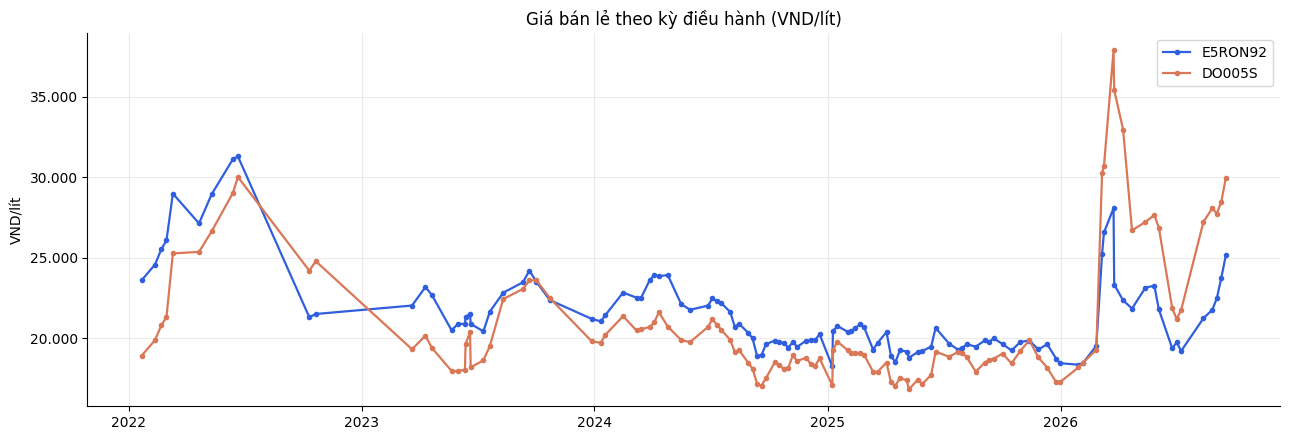

In [3]:
fig, ax = plt.subplots()
for f, col in zip(FUELS, [BLUE, WARM]):
    d = cycles[cycles.fuel == f]
    ax.plot(d.period, d.retail, marker="o", ms=3, lw=1.6, color=col, label=f)
ax.set_title("Giá bán lẻ theo kỳ điều hành (VND/lít)")
ax.set_ylabel("VND/lít"); ax.yaxis.set_major_formatter(VND); ax.legend()
plt.tight_layout(); plt.show()

### 2.2 MOPS (giá MOIT dùng) so với dầu thô Brent

Đây là điểm dễ nhầm nhất của bộ dữ liệu. `world_avg_price` **không phải dầu thô** —
nó là giá **xăng dầu thành phẩm** MOPS Singapore, báo riêng cho từng loại nhiên liệu.
Brent là một con số chung cho mọi loại và thấp hơn đáng kể.

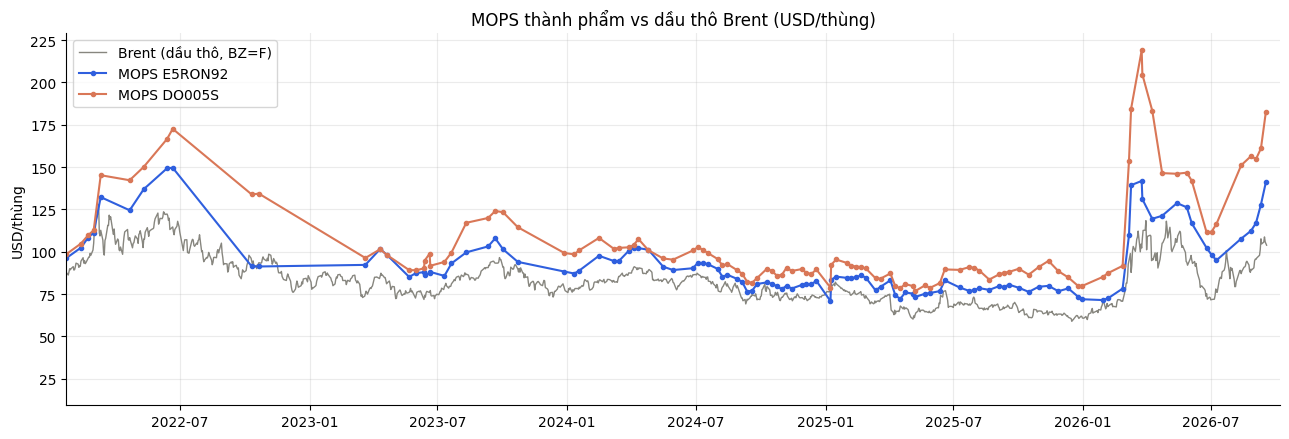

Ngay 2026-09-17:
  MOPS DO005S   =  182.63 USD/thung
  MOPS E5RON92  =  141.09 USD/thung
  Brent      =  103.87 USD/thung  <- khac han


In [4]:
fig, ax = plt.subplots()
ax.plot(BRENT.index, BRENT.values, lw=1, color=MUTE, label="Brent (dầu thô, BZ=F)")
for f, col in zip(FUELS, [BLUE, WARM]):
    d = cycles[cycles.fuel == f]
    ax.plot(d.period, d.world, marker="o", ms=3, lw=1.5, color=col, label=f"MOPS {f}")
ax.set_xlim(cycles.period.min(), cycles.period.max() + pd.Timedelta(days=20))
ax.set_title("MOPS thành phẩm vs dầu thô Brent (USD/thùng)")
ax.set_ylabel("USD/thùng"); ax.legend()
plt.tight_layout(); plt.show()

last = cycles[cycles.period == cycles.period.max()]
print(f"Ngay {cycles.period.max().date()}:")
for _, r in last.iterrows():
    print(f"  MOPS {r.fuel:8s} = {r.world:7.2f} USD/thung")
print(f"  Brent      = {BRENT.iloc[-1]:7.2f} USD/thung  <- khac han")

### 2.3 Quan hệ truyền dẫn: Δthế giới → Δbán lẻ

Đây là nền của cả hai mô hình. Hồi quy qua gốc toạ độ cho hệ số `k` — mỗi USD/thùng
biến động thì giá bán lẻ đổi bao nhiêu đồng/lít.

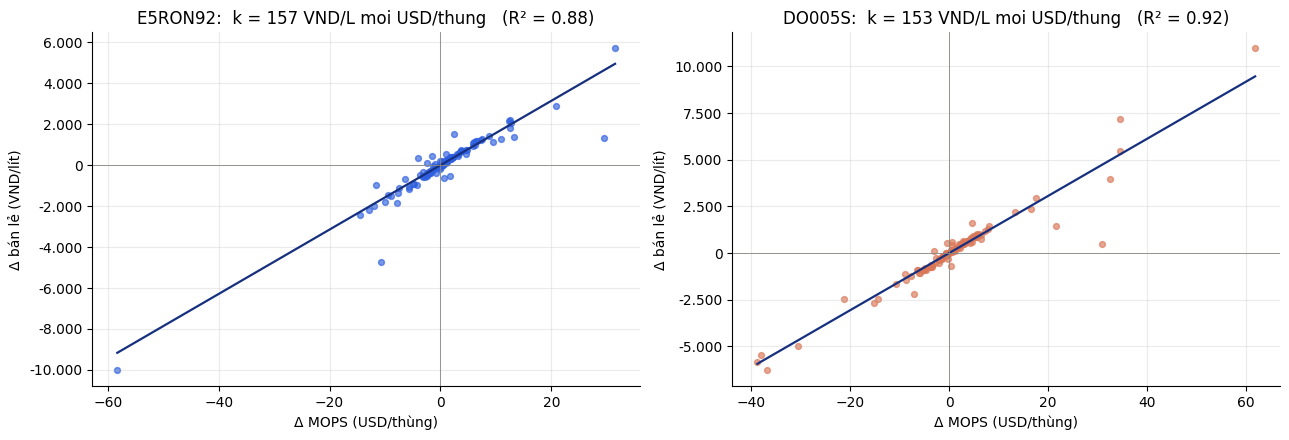

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, f, col in zip(axes, FUELS, [BLUE, WARM]):
    d = cycles[cycles.fuel == f].sort_values("period")
    dw, dr = d.world.diff().dropna(), d.retail.diff().dropna()
    k = float((dw * dr).sum() / (dw ** 2).sum())          # OLS through the origin
    r2 = 1 - ((dr - k * dw) ** 2).sum() / ((dr - dr.mean()) ** 2).sum()
    ax.scatter(dw, dr, s=18, alpha=.65, color=col)
    xs = np.linspace(dw.min(), dw.max(), 50)
    ax.plot(xs, k * xs, color=DARK, lw=1.6)
    ax.axhline(0, color=MUTE, lw=.6); ax.axvline(0, color=MUTE, lw=.6)
    ax.set_title(f"{f}:  k = {k:.0f} VND/L moi USD/thung   (R² = {r2:.2f})")
    ax.set_xlabel("Δ MOPS (USD/thùng)"); ax.set_ylabel("Δ bán lẻ (VND/lít)")
    ax.yaxis.set_major_formatter(VND)
plt.tight_layout(); plt.show()

## 3. Xây dựng đặc trưng

`brent_w7_chg` — thay đổi bình quân Brent 7 ngày so với cửa sổ của kỳ trước.

**Cửa sổ dừng ở ngày t−1**, tức trước khi MOIT công bố lúc ~15:00 ngày t. Không
biến nào chạm vào `world_avg_price` của chính kỳ t.

In [6]:
def brent_window_mean(end, days=7):
    """Mean Brent close over [end-days, end]. `end` is t-1: strictly pre-announcement."""
    w = BRENT.loc[(BRENT.index >= end - pd.Timedelta(days=days)) & (BRENT.index <= end)]
    return (float(w.mean()), len(w)) if len(w) else (np.nan, 0)


def build(fuel, min_days=3):
    d = cycles[cycles.fuel == fuel].sort_values("period").reset_index(drop=True)
    rows = []
    for i in range(1, len(d)):
        cur, prev = d.loc[i], d.loc[i - 1]
        cur_m, n1 = brent_window_mean(cur.period - pd.Timedelta(days=1))
        prv_m, n2 = brent_window_mean(prev.period - pd.Timedelta(days=1))
        if min(n1, n2) < min_days:
            continue
        rows.append({"period": cur.period, "retail": cur.retail, "prev_retail": prev.retail,
                     "d_retail": cur.retail - prev.retail,
                     "d_world": cur.world - prev.world,          # ex-post, model 1 only
                     "brent_w7_chg": cur_m - prv_m})             # pre-announcement, model 2
    return pd.DataFrame(rows)

DATA = {f: build(f) for f in FUELS}
for f, df in DATA.items():
    print(f"{f}: {len(df)} ky dung duoc  {df.period.min().date()} -> {df.period.max().date()}")
DATA["E5RON92"].tail(4)

E5RON92: 116 ky dung duoc  2022-02-11 -> 2026-09-17
DO005S: 116 ky dung duoc  2022-02-11 -> 2026-09-17


,period,retail,prev_retail,d_retail,d_world,brent_w7_chg
112,2026-08-27,21763.0,21235.0,528.0,4.668,6.213332
113,2026-09-03,22486.0,21763.0,723.0,4.628,-0.126668
114,2026-09-10,23744.0,22486.0,1258.0,10.860,6.042000
115,2026-09-17,25139.0,23744.0,1395.0,13.200,8.306335


## 4. Kiểm định walk-forward

Fit lại mô hình ở **mỗi** kỳ, chỉ dùng dữ liệu tới kỳ đó, rồi dự báo kỳ kế tiếp.
Cấm chia ngẫu nhiên vì đây là chuỗi thời gian.

Chuẩn so sánh bắt buộc: **random walk** — "giá giữ nguyên".

In [7]:
MIN_TRAIN = 24

def walk_forward(df):
    """Refit both models at every step. Returns one row per out-of-sample cycle."""
    out = []
    for i in range(MIN_TRAIN, len(df)):
        tr, te = df.iloc[:i], df.iloc[i]
        # Model 1 -- delta-world-v1: needs the CURRENT cycle's MOPS, published only
        # in the same bulletin as the retail price. Ex-post, not a forecast.
        k = float((tr.d_world * tr.d_retail).sum() / (tr.d_world ** 2).sum())
        p_delta = k * te.d_world
        # Model 2 -- brent-nowcast-v1: only pre-announcement data.
        lr = LinearRegression().fit(tr[["brent_w7_chg"]], tr.d_retail)
        p_brent = float(lr.predict([[te.brent_w7_chg]])[0])
        out.append({"period": te.period, "prev_retail": te.prev_retail,
                    "actual": te.d_retail, "delta_world_v1": p_delta,
                    "brent_nowcast_v1": p_brent, "random_walk": 0.0, "k": k})
    return pd.DataFrame(out)

WF = {f: walk_forward(DATA[f]) for f in FUELS}
print({f: len(w) for f, w in WF.items()})
WF["E5RON92"].tail(3)

{'E5RON92': 92, 'DO005S': 92}


,period,prev_retail,actual,delta_world_v1,brent_nowcast_v1,random_walk,k
89,2026-09-03,21763.0,723.0,735.082959,-47.379979,0.0,158.833829
90,2026-09-10,22486.0,1258.0,1724.864483,1118.597394,0.0,158.827300
91,2026-09-17,23744.0,1395.0,2088.813409,1547.215280,0.0,158.243440


In [8]:
def scores(w):
    mae = lambda c: float(np.abs(w.actual - w[c]).mean())
    base = mae("random_walk")
    rows = []
    for c, label in (("random_walk", "Random walk (giá giữ nguyên)"),
                     ("brent_nowcast_v1", "brent-nowcast-v1 (TRƯỚC kỳ)"),
                     ("delta_world_v1", "delta-world-v1 (ex-post)")):
        err = w.actual - w[c]
        moved = w.actual.abs() > 100
        rows.append({"mô hình": label, "MAE (đ/l)": round(mae(c)),
                     "RMSE (đ/l)": round(float(np.sqrt((err ** 2).mean()))),
                     "skill vs RW": round(1 - mae(c) / base, 3),
                     "đúng hướng": "—" if c == "random_walk" else
                        f"{(np.sign(w[c][moved]) == np.sign(w.actual[moved])).mean()*100:.0f}%"})
    return pd.DataFrame(rows)

for f in FUELS:
    print(f"\n===== {f}  (n={len(WF[f])}) =====")
    print(scores(WF[f]).to_string(index=False))


===== E5RON92  (n=92) =====
                     mô hình  MAE (đ/l)  RMSE (đ/l)  skill vs RW đúng hướng
Random walk (giá giữ nguyên)        692        1115        0.000          —
 brent-nowcast-v1 (TRƯỚC kỳ)        513         887        0.258        83%
    delta-world-v1 (ex-post)        199         558        0.712        96%

===== DO005S  (n=92) =====
                     mô hình  MAE (đ/l)  RMSE (đ/l)  skill vs RW đúng hướng
Random walk (giá giữ nguyên)        959        1879        0.000          —
 brent-nowcast-v1 (TRƯỚC kỳ)        600        1239        0.375        89%
    delta-world-v1 (ex-post)        236         610        0.754        98%


### 4.1 Thực tế vs dự báo

Chú ý điểm mấu chốt: `delta-world-v1` bám sát hơn **vì nó đã biết Δthế giới của
chính kỳ đó**. Đó không phải năng lực dự báo — MOIT công bố con số ấy cùng lúc với
giá bán lẻ.

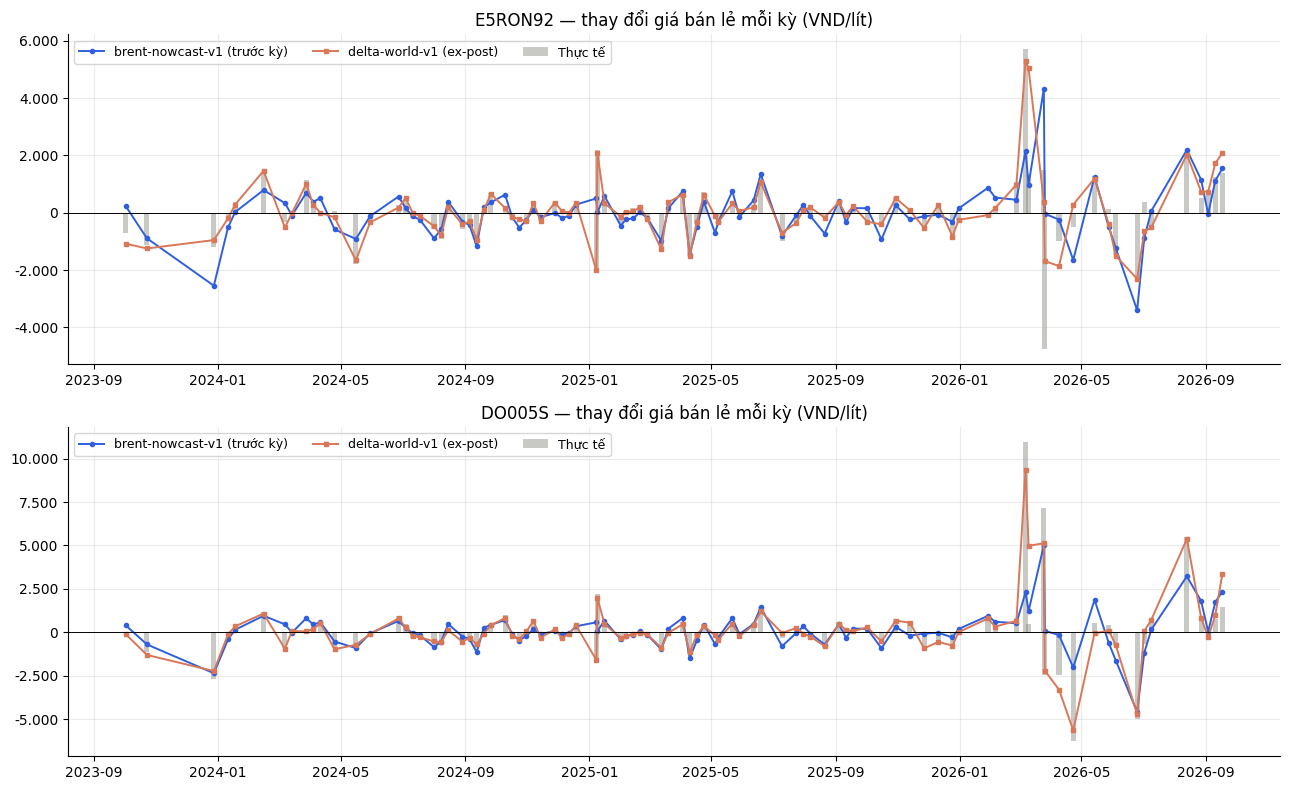

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
for ax, f in zip(axes, FUELS):
    w = WF[f]
    ax.bar(w.period, w.actual, width=5, color=MUTE, alpha=.45, label="Thực tế")
    ax.plot(w.period, w.brent_nowcast_v1, marker="o", ms=3, lw=1.4, color=BLUE,
            label="brent-nowcast-v1 (trước kỳ)")
    ax.plot(w.period, w.delta_world_v1, marker="s", ms=3, lw=1.4, color=WARM,
            label="delta-world-v1 (ex-post)")
    ax.axhline(0, color="black", lw=.7)
    ax.set_title(f"{f} — thay đổi giá bán lẻ mỗi kỳ (VND/lít)")
    ax.yaxis.set_major_formatter(VND); ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

### 4.2 Sai số tích luỹ

Đường nào thấp hơn thì tốt hơn. Độ dốc cho biết mô hình mất chính xác ở giai đoạn nào.

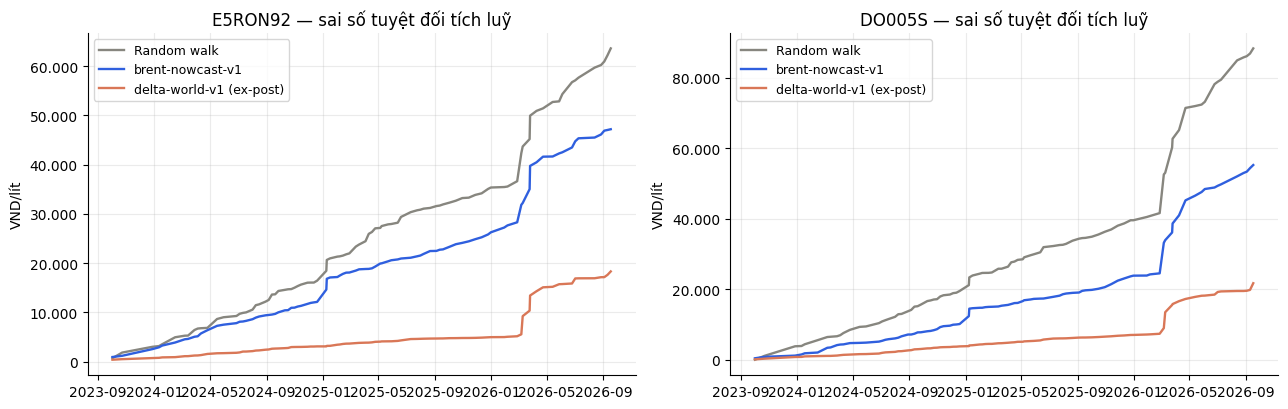

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, f in zip(axes, FUELS):
    w = WF[f]
    for c, label, col in (("random_walk", "Random walk", MUTE),
                          ("brent_nowcast_v1", "brent-nowcast-v1", BLUE),
                          ("delta_world_v1", "delta-world-v1 (ex-post)", WARM)):
        ax.plot(w.period, np.abs(w.actual - w[c]).cumsum(), lw=1.7, color=col, label=label)
    ax.set_title(f"{f} — sai số tuyệt đối tích luỹ"); ax.set_ylabel("VND/lít")
    ax.yaxis.set_major_formatter(VND); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 4.3 Tín hiệu tắt dần theo tầm dự báo

Đây là biểu đồ quyết định việc **được phép hứa gì với khách hàng**.

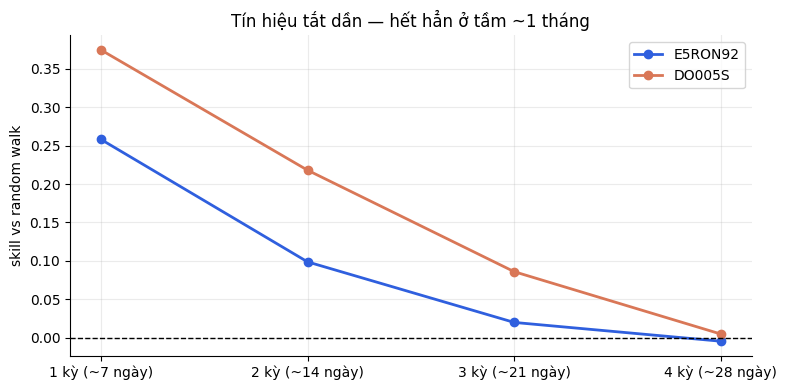

,E5RON92,DO005S
1 kỳ (~7 ngày),0.258,0.375
2 kỳ (~14 ngày),0.099,0.218
3 kỳ (~21 ngày),0.020,0.086
4 kỳ (~28 ngày),-0.005,0.005


In [11]:
def skill_at_lead(fuel, lead):
    """Skill when the target is `lead` cycles ahead but features still stop at t-1."""
    d = cycles[cycles.fuel == fuel].sort_values("period").reset_index(drop=True)
    rows = []
    for i in range(1, len(d) - lead + 1):
        cur_m, n1 = brent_window_mean(d.loc[i, "period"] - pd.Timedelta(days=1))
        prv_m, n2 = brent_window_mean(d.loc[i-1, "period"] - pd.Timedelta(days=1))
        if min(n1, n2) < 3:
            continue
        rows.append({"x": cur_m - prv_m,
                     "y": d.loc[i+lead-1, "retail"] - d.loc[i-1, "retail"]})
    df = pd.DataFrame(rows)
    preds, truth = [], []
    for i in range(MIN_TRAIN, len(df)):
        lr = LinearRegression().fit(df.iloc[:i][["x"]], df.iloc[:i].y)
        preds.append(float(lr.predict([[df.iloc[i].x]])[0])); truth.append(df.iloc[i].y)
    truth, preds = np.array(truth), np.array(preds)
    base = np.abs(truth).mean()
    return 1 - np.abs(truth - preds).mean() / base

LEADS = [1, 2, 3, 4]
decay = pd.DataFrame({f: [skill_at_lead(f, L) for L in LEADS] for f in FUELS},
                     index=[f"{L} kỳ (~{L*7} ngày)" for L in LEADS])
fig, ax = plt.subplots(figsize=(8, 4))
for f, col in zip(FUELS, [BLUE, WARM]):
    ax.plot(range(len(LEADS)), decay[f], marker="o", lw=2, color=col, label=f)
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_xticks(range(len(LEADS))); ax.set_xticklabels(decay.index)
ax.set_ylabel("skill vs random walk"); ax.legend()
ax.set_title("Tín hiệu tắt dần — hết hẳn ở tầm ~1 tháng")
plt.tight_layout(); plt.show()
decay.round(3)

## 5. Dự báo tương lai

Hai mô hình cho **hai loại đầu ra khác nhau**, và đó chính là điểm cần hiểu:

- `brent-nowcast-v1` ra **một con số**, vì đầu vào của nó đã quan sát được.
- `delta-world-v1` **không ra được con số nào** nếu chưa biết Δthế giới — nên nó
  chỉ trình bày **kịch bản** theo các mức biến động giả định.

In [12]:
CYCLE_DAYS = 7          # cadence has been weekly since 2026-09-03
Z80 = 1.2816            # 80% band of a normal

def forecast_next(fuel):
    df, d = DATA[fuel], cycles[cycles.fuel == fuel].sort_values("period")
    last_period, last_retail = d.period.iloc[-1], d.retail.iloc[-1]
    nxt = last_period + pd.Timedelta(days=CYCLE_DAYS)

    # --- Model 2: a real number, from Brent observed up to the day before ---
    cur_m, n_cur = brent_window_mean(min(nxt - pd.Timedelta(days=1), BRENT.index.max()))
    prv_m, _ = brent_window_mean(last_period - pd.Timedelta(days=1))
    lr = LinearRegression().fit(df[["brent_w7_chg"]], df.d_retail)
    d_brent = cur_m - prv_m
    p_brent = float(lr.predict([[d_brent]])[0])
    resid_sd = float((df.d_retail - lr.predict(df[["brent_w7_chg"]])).std())

    # --- Model 1: scenarios, because d_world for the next cycle is unknown ---
    k = float((df.d_world * df.d_retail).sum() / (df.d_world ** 2).sum())
    sigma_w = float(df.d_world.std())
    scen = {f"{lbl} (Δthế giới {m*sigma_w:+.1f})": last_retail + k * m * sigma_w
            for lbl, m in (("Thấp", -Z80), ("Cơ sở", 0.0), ("Cao", +Z80))}

    return {"fuel": fuel, "last_period": last_period, "next_period": nxt,
            "last_retail": last_retail, "d_brent": d_brent, "n_brent_days": n_cur,
            "nowcast": last_retail + p_brent, "nowcast_delta": p_brent,
            "nowcast_lo": last_retail + p_brent - Z80 * resid_sd,
            "nowcast_hi": last_retail + p_brent + Z80 * resid_sd,
            "k": k, "sigma_world": sigma_w, "scenarios": scen}

FC = {f: forecast_next(f) for f in FUELS}
for f, r in FC.items():
    print(f"\n===== {f} =====")
    print(f"  Ky gan nhat   : {r['last_period'].date()}  {r['last_retail']:,.0f} d/l")
    print(f"  Ky du bao     : {r['next_period'].date()}")
    print(f"  Cua so Brent  : {r['n_brent_days']}/7 ngay da quan sat, "
          f"thay doi {r['d_brent']:+.2f} USD/thung")
    print(f"  --- brent-nowcast-v1 (mot con so) ---")
    print(f"    Du bao      : {r['nowcast']:,.0f} d/l  ({r['nowcast_delta']:+,.0f})")
    print(f"    Khoang 80%  : {r['nowcast_lo']:,.0f} - {r['nowcast_hi']:,.0f} d/l")
    print(f"  --- delta-world-v1 (kich ban, k={r['k']:.0f}) ---")
    for lbl, v in r["scenarios"].items():
        print(f"    {lbl:34s}: {v:,.0f} d/l")


===== E5RON92 =====
  Ky gan nhat   : 2026-09-17  25,139 d/l
  Ky du bao     : 2026-09-24
  Cua so Brent  : 6/7 ngay da quan sat, thay doi -0.02 USD/thung
  --- brent-nowcast-v1 (mot con so) ---
    Du bao      : 25,117 d/l  (-22)
    Khoang 80%  : 23,816 - 26,419 d/l
  --- delta-world-v1 (kich ban, k=157) ---
    Thấp (Δthế giới -11.2)            : 23,372 d/l
    Cơ sở (Δthế giới +0.0)            : 25,139 d/l
    Cao (Δthế giới +11.2)             : 26,906 d/l

===== DO005S =====
  Ky gan nhat   : 2026-09-17  29,945 d/l
  Ky du bao     : 2026-09-24
  Cua so Brent  : 6/7 ngay da quan sat, thay doi -0.02 USD/thung
  --- brent-nowcast-v1 (mot con so) ---
    Du bao      : 29,989 d/l  (+44)
    Khoang 80%  : 28,468 - 31,510 d/l
  --- delta-world-v1 (kich ban, k=153) ---
    Thấp (Δthế giới -15.6)            : 27,553 d/l
    Cơ sở (Δthế giới +0.0)            : 29,945 d/l
    Cao (Δthế giới +15.6)             : 32,337 d/l


### 5.1 Biểu đồ dự báo

Lịch sử liền nét, dự báo đứt nét. Vùng xám là dải kịch bản 80% của
`delta-world-v1`; chấm xanh kèm thanh sai số là con số của `brent-nowcast-v1`.

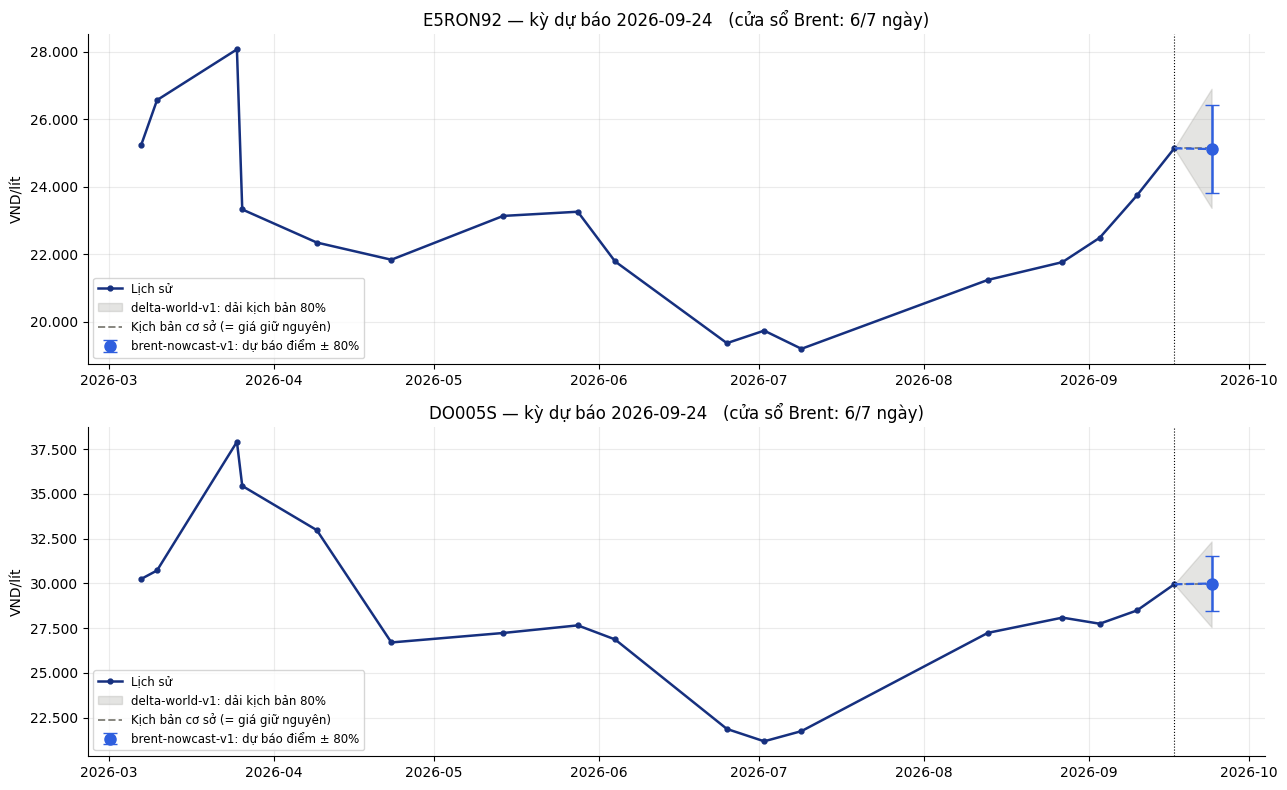

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, f in zip(axes, FUELS):
    r, d = FC[f], cycles[cycles.fuel == f].sort_values("period")
    hist = d[d.period >= d.period.max() - pd.Timedelta(days=200)]
    ax.plot(hist.period, hist.retail, marker="o", ms=3.5, lw=1.8, color=DARK, label="Lịch sử")

    lo = min(r["scenarios"].values()); hi = max(r["scenarios"].values())
    ax.fill_between([r["last_period"], r["next_period"]],
                    [r["last_retail"], lo], [r["last_retail"], hi],
                    color=MUTE, alpha=.22, label="delta-world-v1: dải kịch bản 80%")
    ax.plot([r["last_period"], r["next_period"]],
            [r["last_retail"], r["scenarios"][[k for k in r["scenarios"] if k.startswith("Cơ sở")][0]]],
            ls="--", lw=1.4, color=MUTE, label="Kịch bản cơ sở (= giá giữ nguyên)")

    ax.errorbar([r["next_period"]], [r["nowcast"]],
                yerr=[[r["nowcast"] - r["nowcast_lo"]], [r["nowcast_hi"] - r["nowcast"]]],
                fmt="o", ms=8, color=BLUE, capsize=5, lw=1.8,
                label="brent-nowcast-v1: dự báo điểm ± 80%")
    ax.plot([r["last_period"], r["next_period"]], [r["last_retail"], r["nowcast"]],
            ls="--", lw=1.6, color=BLUE)
    ax.axvline(r["last_period"], color="black", lw=.8, ls=":")
    ax.set_title(f"{f} — kỳ dự báo {r['next_period'].date()}"
                 f"   (cửa sổ Brent: {r['n_brent_days']}/7 ngày)")
    ax.set_ylabel("VND/lít"); ax.yaxis.set_major_formatter(VND); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

## 6. Đối chiếu với VPI — mốc so sánh thật trên thị trường

**Viện Dầu khí Việt Nam (VPI)**, đơn vị thuộc Tập đoàn Dầu khí Việt Nam, công bố
dự báo giá xăng dầu **trước mỗi kỳ điều hành**, cho cả 5 loại nhiên liệu, bằng
mạng nơ-ron nhân tạo (ANN) + supervised learning. Phát miễn phí qua VietnamPlus,
BNews (TTXVN), PetroTimes, Thời báo Tài chính, HTV, PVOIL.

Khác biệt cốt lõi so với mô hình của chúng ta: **VPI dự báo cả hành động của Quỹ
bình ổn** — đúng thứ mà mục 7 liệt kê là nguồn sai số lớn nhất ta không xử lý được.

Dưới đây là dự báo VPI đã công bố, đối chiếu với giá thật trong DB.

In [14]:
# VPI forecasts as published in state media, paired with the cycle they targeted.
# Collected 2026-09-20 from VietnamPlus, BNews (TTXVN) and PetroTimes.
VPI_PUBLISHED = [
    ("2025-04-24", "E5RON92", 19193), ("2025-04-24", "DO005S", 17405),
    ("2026-01-29", "E5RON92", 18371), ("2026-01-29", "DO005S", 18178),
    ("2026-02-05", "E5RON92", 18642),
    ("2026-02-26", "E5RON92", 19523),
]

vpi = pd.DataFrame(VPI_PUBLISHED, columns=["period", "fuel", "vpi_forecast"])
vpi["period"] = pd.to_datetime(vpi.period)
vpi = vpi.merge(cycles[["period", "fuel", "retail"]], on=["period", "fuel"], how="left")
vpi["sai_so"] = vpi.vpi_forecast - vpi.retail
vpi["pct"] = (vpi.sai_so.abs() / vpi.retail * 100).round(2)
vpi.rename(columns={"retail": "thuc_te"})

,period,fuel,vpi_forecast,thuc_te,sai_so,pct
0,2025-04-24,E5RON92,19193,19238.0,-45.0,0.23
1,2025-04-24,DO005S,17405,17524.0,-119.0,0.68
2,2026-01-29,E5RON92,18371,18339.0,32.0,0.17
3,2026-01-29,DO005S,18178,18173.0,5.0,0.03
4,2026-02-05,E5RON92,18642,18439.0,203.0,1.10
5,2026-02-26,E5RON92,19523,19523.0,0.0,0.00


In [15]:
# Our models' MAE comes from the walk-forward above; VPI's from the table.
rows = []
for f in FUELS:
    w, v = WF[f], vpi[vpi.fuel == f]
    rows.append({
        "fuel": f,
        "n mẫu VPI": len(v),
        "VPI": round(v.sai_so.abs().mean()) if len(v) else np.nan,
        "delta-world-v1 (ex-post)": round(np.abs(w.actual - w.delta_world_v1).mean()),
        "brent-nowcast-v1 (trước kỳ)": round(np.abs(w.actual - w.brent_nowcast_v1).mean()),
        "Giá giữ nguyên": round(np.abs(w.actual).mean()),
    })
comp = pd.DataFrame(rows).set_index("fuel")
print("MAE — sai so tuyet doi trung binh (VND/lit), THAP hon = TOT hon\n")
print(comp.to_string())
print("\nVPI chinh xac hon brent-nowcast-v1:")
for f in FUELS:
    r = comp.loc[f]
    if not np.isnan(r["VPI"]):
        print(f"  {f}: {r['brent-nowcast-v1 (trước kỳ)'] / r['VPI']:.1f} lan")

MAE — sai so tuyet doi trung binh (VND/lit), THAP hon = TOT hon

         n mẫu VPI  VPI  delta-world-v1 (ex-post)  brent-nowcast-v1 (trước kỳ)  Giá giữ nguyên
fuel                                                                                          
E5RON92          4   70                       199                          513             692
DO005S           2   62                       236                          600             959

VPI chinh xac hon brent-nowcast-v1:
  E5RON92: 7.3 lan
  DO005S: 9.7 lan


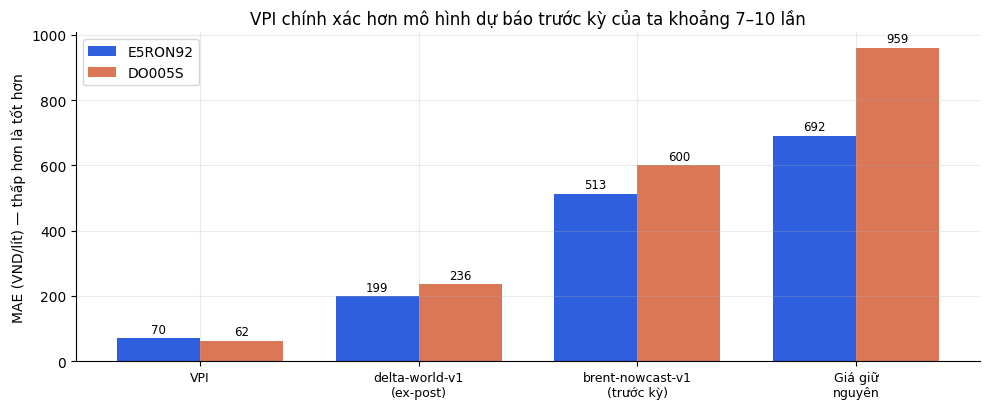

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.2))
labels = ["VPI", "delta-world-v1\n(ex-post)", "brent-nowcast-v1\n(trước kỳ)", "Giá giữ\nnguyên"]
x = np.arange(len(labels)); w_ = 0.38
for i, (f, col) in enumerate(zip(FUELS, [BLUE, WARM])):
    v = vpi[vpi.fuel == f]; wf = WF[f]
    vals = [v.sai_so.abs().mean() if len(v) else np.nan,
            np.abs(wf.actual - wf.delta_world_v1).mean(),
            np.abs(wf.actual - wf.brent_nowcast_v1).mean(),
            np.abs(wf.actual).mean()]
    b = ax.bar(x + (i - .5) * w_, vals, w_, color=col, label=f)
    ax.bar_label(b, fmt="%.0f", fontsize=8.5, padding=2)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("MAE (VND/lít) — thấp hơn là tốt hơn"); ax.legend()
ax.set_title("VPI chính xác hơn mô hình dự báo trước kỳ của ta khoảng 7–10 lần")
plt.tight_layout(); plt.show()

### 6.1 Đọc kết quả này thế nào

VPI sai khoảng **60–75 đ/l**; mô hình dự báo-trước-kỳ của ta sai **508–602 đ/l**.
VPI còn chính xác hơn cả `delta-world-v1` — mô hình *đã biết* giá thế giới của kỳ
đó — khoảng 3 lần.

**Cảnh báo về cỡ mẫu:** n=4 (E5RON92) và n=2 (DO005S), thu từ các bài báo tìm
được. Có khả năng báo chí chỉ đăng những kỳ VPI đoán trúng. Nhưng chênh lệch
7–10 lần vượt xa mức nhiễu mà cỡ mẫu nhỏ giải thích được. Muốn chắc chắn thì
phải thu thập 20–30 kỳ rồi đo lại.

**Hệ quả sản phẩm:** không thể bán một dự báo giá xăng kém chính xác hơn nhiều
lần so với một dự báo miễn phí, do viện nghiên cứu nhà nước phát trên thông tấn
quốc gia. Điều này đúng với **cả hai** mô hình trong notebook này.

## 7. Kết luận

### 7.1 Về hai mô hình

| | |
|---|---|
| Tầm dùng được | **1 kỳ (~7 ngày)**, không phải 1 tháng — xem mục 4.3 |
| Bản chất | Nowcast: cửa sổ tham chiếu gần như đã quan sát xong khi dự báo |
| Điều kiện | Phải fit lại mỗi kỳ; train một lần rồi để yên → skill ≈ 0 |
| Khoảng tin cậy | Gaussian **chưa hợp lệ** (phần dư không chuẩn) — cần bootstrap |
| Chưa xử lý được | Can thiệp tuỳ nghi của Quỹ bình ổn và điều chỉnh thuế |

### 7.2 Về định hướng sản phẩm

Mục 6 cho thấy **VPI đã làm tốt hơn ta nhiều lần, miễn phí**. Vì vậy hướng "bán
dự báo giá xăng" không còn cơ sở cạnh tranh.

Hướng còn giá trị, vì **VPI không cung cấp**:

1. **Lịch sử sạch, có API** — 117 kỳ điều hành, 2 loại nhiên liệu, kèm giá MOPS
   mà MOIT công bố. VPI chỉ phát dự báo rời rạc qua báo chí, không có kho dữ liệu.
2. **Đối chiếu dự báo với kết quả thật** — lưu lại dự báo VPI mỗi kỳ rồi so với
   giá thực tế, công bố độ chính xác theo thời gian. Không ai đang làm việc này,
   kể cả VPI.

Hướng 2 biến điểm yếu thành sản phẩm: ta không dự báo giỏi hơn, nhưng ta **đo
được ai dự báo giỏi** — và đó là thông tin một doanh nghiệp vận tải cần để biết
có nên tin con số nào.

> **Chưa triển khai gì lên production.** Model đang chạy vẫn là `delta-world-v1`.
> Việc thu thập và tái sử dụng dữ liệu VPI còn vướng điều kiện pháp lý (Nghị định
> 72/2013 về trang thông tin điện tử tổng hợp) — phải làm rõ trước khi xây.